<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1
-----

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def sample_pp(T_max=100, lam=1):
  pois = np.random.poisson(lam*T_max)
  jumps = np.sort(np.random.uniform(0, T_max, pois))
  return jumps

In [10]:
print(sample_pp(), len(sample_pp()))

[ 1.17308412  1.25311156  1.34565506  1.60372257  1.61528252  3.57185987
  5.91300761  7.1921905   9.60458542 10.89277865 11.43571261 11.6471167
 11.85011636 12.28668516 13.99560292 14.59162217 14.78382191 15.32788777
 15.3600212  15.92303429 16.09618309 16.45122066 17.72035776 17.84293134
 17.86622438 18.32173126 19.2801457  21.84298594 22.93403848 23.73061575
 26.13618128 26.23159023 27.22924237 28.36423016 29.61756514 29.68422119
 31.72854466 33.31832921 34.24261997 35.39523521 35.63701052 38.64932559
 39.45484535 40.68169963 40.92927544 42.27641085 42.86584037 43.63712713
 46.46410597 47.54651031 47.62909223 48.10427664 48.81632644 50.08312668
 50.84323647 51.76655726 51.86305878 52.02456174 54.0170867  54.11644775
 56.17744126 56.36303725 58.30426817 58.97828329 59.4808915  61.02507802
 61.8312737  62.11248789 62.61363987 62.82654751 63.04459868 63.6729886
 64.42285646 64.45969445 65.17550475 65.90489807 66.00421307 66.44442852
 66.75795752 69.29474339 69.52741788 69.73496993 69.9

In [11]:
def thin_pp(jumps=sample_pp(), p=0.4):
  u = np.random.rand(len(jumps))
  jumps_new = []
  for i in range(len(jumps)):
    if u[i] < p:
      jumps_new.append(jumps[i])
  return jumps_new

In [25]:
data = sample_pp()
data_new = thin_pp(data)

In [20]:
print(data_new, len(data_new))

[np.float64(1.896696731820724), np.float64(6.2304961337131815), np.float64(6.372743822611571), np.float64(6.938411824578939), np.float64(7.415858837710765), np.float64(8.62660467667956), np.float64(12.354078014211334), np.float64(12.515155545763035), np.float64(13.690783525461736), np.float64(15.120675162849528), np.float64(16.828279707473904), np.float64(16.89836065608241), np.float64(16.90607815535934), np.float64(18.439717979217328), np.float64(20.115341472710014), np.float64(21.96246193593634), np.float64(22.627748539282656), np.float64(23.025866481161582), np.float64(27.94778614261373), np.float64(34.303835823678156), np.float64(37.11820691111133), np.float64(38.552521555622896), np.float64(41.93491786842033), np.float64(42.54868307820979), np.float64(43.16279790997217), np.float64(55.353585661251536), np.float64(60.85872314002195), np.float64(63.300098888911), np.float64(67.25069915201559), np.float64(67.62531859814591), np.float64(69.60679475778642), np.float64(71.21216139477707

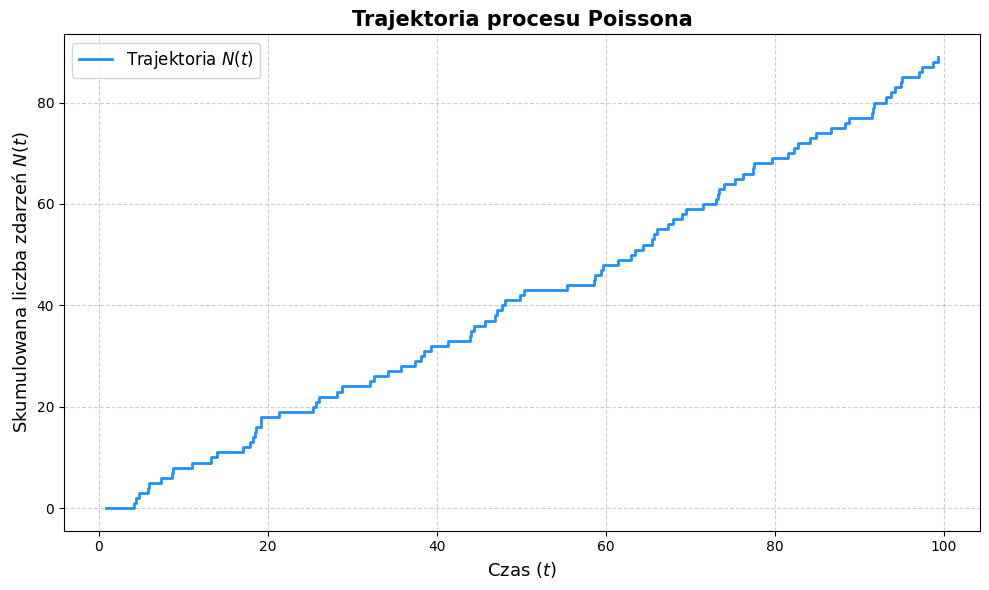

In [32]:

t = [0] + data

N = list(range(len(t)))

plt.figure(figsize=(10, 6))


plt.step(t, N, where='post', color='dodgerblue', linewidth=2, label='Trajektoria $N(t)$')


plt.title("Trajektoria procesu Poissona", fontsize=15, fontweight='bold')
plt.xlabel("Czas ($t$)", fontsize=13)
plt.ylabel("Skumulowana liczba zdarzeń $N(t)$", fontsize=13)


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')


#plt.hlines(y=N[-1], xmin=t[-1], xmax=t[-1] + 1.5, color='dodgerblue', linewidth=2)

plt.tight_layout()
plt.show()

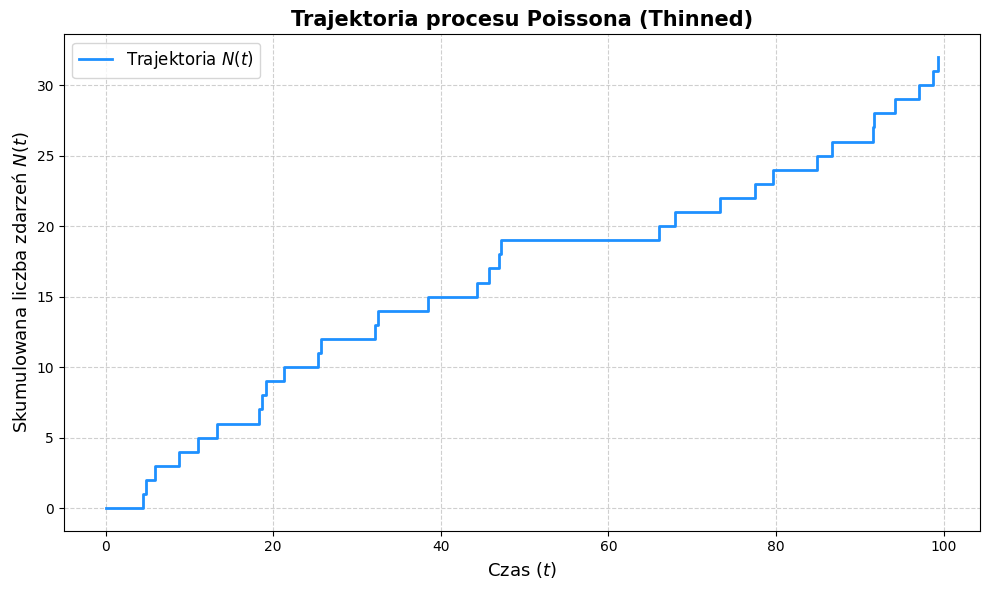

In [33]:

t = [0] + data_new

N = list(range(len(t)))

plt.figure(figsize=(10, 6))


plt.step(t, N, where='post', color='dodgerblue', linewidth=2, label='Trajektoria $N(t)$')


plt.title("Trajektoria procesu Poissona (Thinned)", fontsize=15, fontweight='bold')
plt.xlabel("Czas ($t$)", fontsize=13)
plt.ylabel("Skumulowana liczba zdarzeń $N(t)$", fontsize=13)


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')


#plt.hlines(y=N[-1], xmin=t[-1], xmax=t[-1] + 1.5, color='dodgerblue', linewidth=2)

plt.tight_layout()
plt.show()

## Taks 2
-----

In [34]:
def Markov_MC_sampler(alpha=0.5, beta=0.5, x0=1, n=100):
  x_current = x0
  results = []
  for _ in range(n):
    results.append(x_current)
    u = np.random.rand()
    if x_current == 1:
      if u < alpha:
        x_current = 2
      else:
        x_current = 1
    else:
      if u < beta:
        x_current = 1
      else:
        x_current = 2
  return results

In [38]:
data = Markov_MC_sampler(alpha=0.1, beta=0.2, n=100000)

In [39]:
unique, counts = np.unique(data, return_counts=True)

In [40]:
unique, counts

(array([1, 2]), array([66725, 33275]))

In [41]:
print("Probability X_n = 1:", counts[0]/(counts[0]+counts[1]))
print("Probability X_n = 1:", counts[1]/(counts[0]+counts[1]))

Probability X_n = 1: 0.66725
Probability X_n = 1: 0.33275
